In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
male_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='Male')
female_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='Female')

In [3]:
import os
# os.chdir('./raw_data/')

In [4]:
# male_df = pd.read_csv('male_data.csv')
# female_df = pd.read_csv('female_data.csv')

In [5]:
male_df.rename(columns={"LDL ": "LDL", "smoking(Y/N/Q)": "smoking(N/Y/Q)"}, inplace=True)
female_df.rename(columns={"LDL ": "LDL", "smoking(Y/N/Q)": "smoking(N/Y/Q)"}, inplace=True)

In [6]:
df_combined = pd.concat([female_df, male_df]) 
# before I drop the 'sex' feature from both dataframes 
# (need a combined df to draw side by side plots later on)

In [7]:
categorical_features = ['tPA(0/1)','EVT(0/1)','HTN(0/1)','DM(0/1)','Dyslipidemia(0/1)','Af(0/1)','smoking(N/Y/Q)', 'MRS']

In [8]:
label = 'Second_Stroke'

In [9]:
cont_features = ['age', 'HLOS', 'NIHSS', 'LDL', 'cholesterol', 'TG', 'Cre', 'SGPT', 'HbA1c']

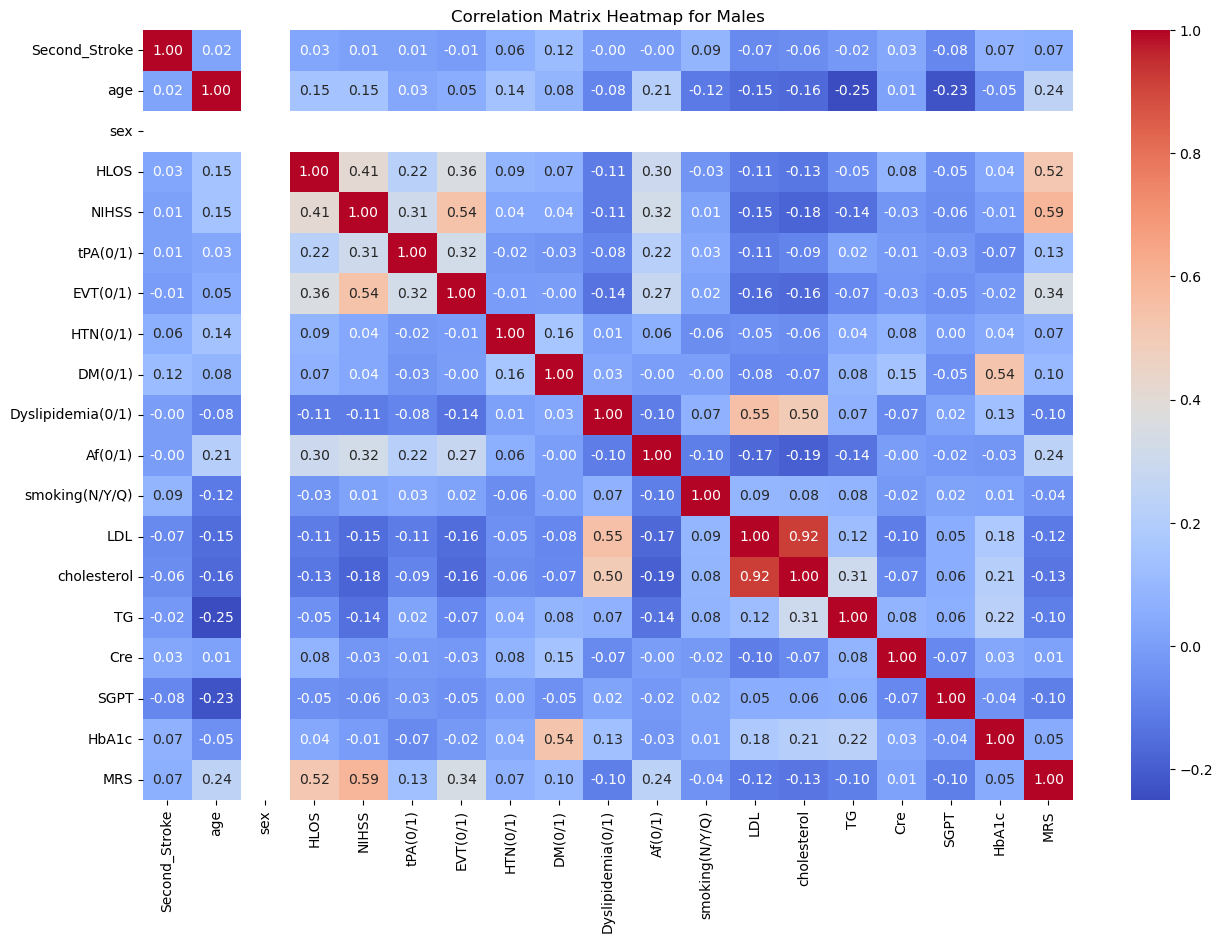

In [10]:
correlation_matrix = male_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

# Using the correlation_matrix from above
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap for Males')
plt.show()

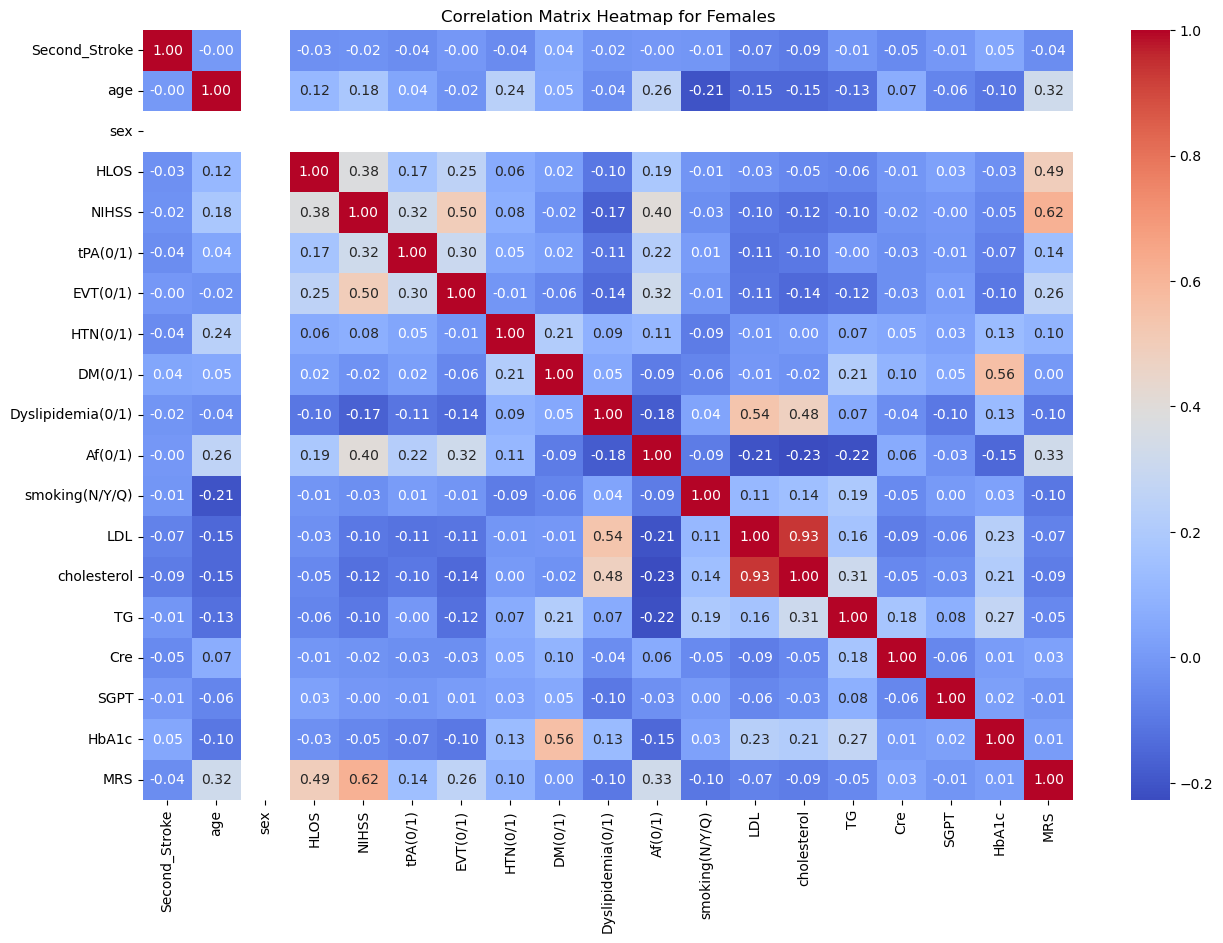

In [11]:
correlation_matrix = female_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

# Using the correlation_matrix from above
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap for Females')
plt.show()

In [12]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# for i in range(len(categorical_features)):
    
#     # Get counts for each feature manually
#     female_counts = female_df[categorical_features[i]].value_counts().sort_index()
#     male_counts = male_df[categorical_features[i]].value_counts().sort_index()
    
#     # Get x locations
#     x = np.arange(len(female_counts.index))
#     width = 0.4
    
#     plt.figure(figsize=(8,6))
#     plt.bar(x - width/2, female_counts.values, width=width, color='pink', label='Female', alpha=0.7)
#     plt.bar(x + width/2, male_counts.values, width=width, color='skyblue', label='Male', alpha=0.7)
    
#     plt.xticks(x, female_counts.index)
#     plt.xlabel(categorical_features[i])
#     plt.ylabel('Count')
#     plt.title('Female vs Male Comparison by Feature')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

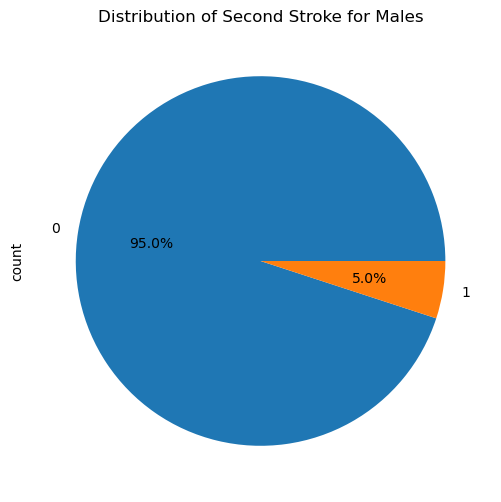

In [13]:
# sns.countplot(x='Second_Stroke', data=male_df)

category_counts = male_df['Second_Stroke'].value_counts()
# Plot the pie chart
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Males')

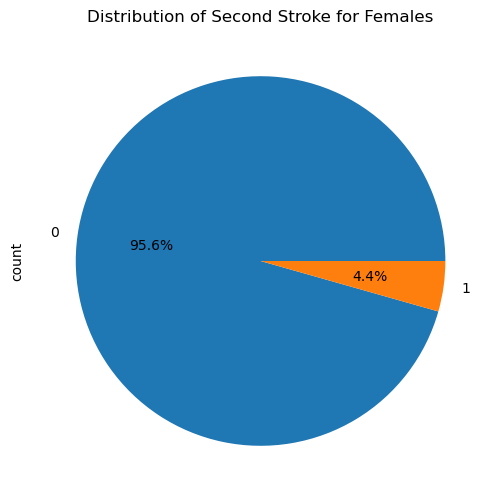

In [14]:
category_counts = female_df['Second_Stroke'].value_counts()
# Plot the pie chart
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Females')

In [15]:
male_df['Second_Stroke'].value_counts()

Second_Stroke
0    870
1     46
Name: count, dtype: int64

In [16]:
male_df['smoking(N/Y/Q)'].value_counts()

smoking(N/Y/Q)
0    470
1    321
2    125
Name: count, dtype: int64

In [17]:
female_df['Second_Stroke'].value_counts()

Second_Stroke
0    543
1     25
Name: count, dtype: int64

In [18]:
female_df['smoking(N/Y/Q)'].value_counts()

smoking(N/Y/Q)
0    541
1     25
2      2
Name: count, dtype: int64

In [19]:
# 有二次中風的女性只有一個沒抽煙： （24/25人）是有二次中風且都有抽煙，且其中有10人大於73歲
female_df[(female_df["smoking(Y/N/Q)"] == 0) & (female_df["Second_Stroke"] == 1)]
female_df[(female_df["smoking(Y/N/Q)"] == 0) & (female_df["Second_Stroke"] == 1) & (female_df["age"] > 73)]

KeyError: 'smoking(Y/N/Q)'

In [ ]:
female_df[(female_df["Second_Stroke"] == 1) & (female_df["Af(0/1)"] == 0)]

In [ ]:
# 沒有二次中風但有抽煙的女性: 517人（517/541人）
female_df[(female_df["smoking(Y/N/Q)"] == 0) & (female_df["Second_Stroke"] == 0)]

In [ ]:
features = cont_features
fig, axes = plt.subplots(3, 3, figsize=(15, 20))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df_combined, x='sex', y=feature, hue='sex', palette=['skyblue', 'pink'], ax=ax)
    ax.set_title(f'{feature} by Gender')
    ax.set_xlabel('')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [ ]:
features = categorical_features
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for ax, feature in zip(axes.flatten(), features):
    sns.countplot(
        data=df_combined,
        x=feature,
        hue='sex',
        # palette=['#ff9a8a', '#fbdd7e', '#a2cffe'],
        palette=['skyblue', 'pink'],
        ax=ax
    )
    ax.set_title(f'{feature} by Gender')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend(title='sex')

plt.tight_layout()
plt.show()

In [ ]:
# create summary function
def summary_stats(x):
    return pd.Series({
        'Mean': x.mean(),
        'Std': x.std(),
        'Median': x.median(),
        'Min': x.min(),
        'Max': x.max()
    })

features = cont_features

# apply by group
summary_table = (
    df_combined
    .groupby('sex')[features]
    .apply(lambda df: df.apply(summary_stats))
    .swaplevel(axis=0)
    .sort_index(level=0)
)

# round and print
summary_table = summary_table.round(2)
display(summary_table)

In [ ]:
# 1. 看中位數差距 (實際差多少)：計算各組中位數與百分比差距

for feature in cont_features:
    meds = df_combined.groupby('sex')[feature].median()
    min_med = meds.min()
    max_med = meds.max()
    diff = max_med - min_med
    pct_diff = (diff / min_med * 100) if min_med != 0 else np.nan
    print(f"{feature}: medians = {meds.to_dict()}, "
          f"range = {diff:.2f}, "
          f"percent_diff = {pct_diff:.1f}%")